# Tutorial 2 — Autoencoders and Variational Autoencoders (VAE)

This notebook introduces generative modelling with Autoencoders and Variational Autoencoders using the **MNIST** handwritten digit dataset.

## Learning Outcomes
By the end of this lab you will be able to:
- Load and visualise the MNIST image dataset in PyTorch
- Build and train a standard Autoencoder using `nn.Module`
- Visualise reconstructions and the latent space
- Explain why a standard Autoencoder is poor at generation
- Implement the Reparameterisation Trick
- Build and train a Variational Autoencoder (VAE)
- Compute the VAE loss (Reconstruction + KL divergence)
- Generate new images by sampling from the latent space
- Interpolate between two digits in latent space

---


---
## Part 1: The MNIST Dataset

**MNIST** (Modified National Institute of Standards and Technology) is the "hello world" of image datasets.
It contains **70,000 greyscale images** of handwritten digits (0–9), each **28×28 pixels**.

| Split | Samples |
|-------|---------|
| Training | 60,000 |
| Test | 10,000 |

### Why MNIST for Autoencoders?
- Images are small (28×28 = 784 pixels) so models train quickly on CPU
- There is clear structure and patterns for the model to learn
- We can visually judge whether reconstructions and generated samples look sensible

### Image shape in PyTorch
PyTorch image tensors use **channel-first** format:
```
(batch_size, channels, height, width)
      ↓          ↓        ↓       ↓
  (64,          1,       28,     28)   ← one batch of 64 greyscale MNIST images
```
For a fully-connected Autoencoder we flatten each image to a 1-D vector of length **784**.


### Step 1 — Import libraries and detect the device

We import the same libraries as Tutorial 1 plus `torchvision`, which provides ready-made image
datasets (including MNIST) and common image transformations.

The device detection block is identical to Tutorial 1 — it automatically picks GPU if available,
otherwise falls back to CPU.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ── Device detection 
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)


Using device: cpu


### Step 2 — Download MNIST and create DataLoaders

Two transformations are applied to every image before it enters the model:

| Transform | What it does | Why |
|-----------|-------------|-----|
| `ToTensor()` | Converts a PIL image (0–255 integer) to a float32 tensor (0.0–1.0) | PyTorch works with tensors, not PIL images |
| `Normalize((0.5,),(0.5,))` | Shifts and scales: `pixel = (pixel − 0.5) / 0.5` → range (−1, 1) | Centred data trains faster and more stably |

> **Important:** We use `Normalize` with mean=0.5 and std=0.5, so pixels end up in the range **−1 to 1**.
> This means the Autoencoder output activation must also produce values in **−1 to 1** — we use `Tanh` for this reason.

The `DataLoader` wraps the dataset and handles:
- **Batching**: groups 128 images per forward pass
- **Shuffling**: randomises order each epoch (training only — keeps validation deterministic)


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # pixel → (pixel - 0.5) / 0.5  → range (-1, 1)
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)   # shuffle=True for training
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)  # shuffle=False for evaluation

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Image shape      : {train_dataset[0][0].shape}")     # (channels, height, width)
print(f"Pixel range      : [{train_dataset[0][0].min():.2f}, {train_dataset[0][0].max():.2f}]")
print(f"Number of batches (train): {len(train_loader)}")


Training samples : 60,000
Test samples     : 10,000
Image shape      : torch.Size([1, 28, 28])
Pixel range      : [-1.00, 1.00]
Number of batches (train): 469


### Step 3 — Visualise sample digits

Before building any model it is good practice to look at the data.
We plot 20 sample images so we know what we are working with.

Note the `.squeeze()` call: images have shape `(1, 28, 28)` (channel, height, width).
`squeeze()` removes the channel dimension to give `(28, 28)` which `imshow` expects.


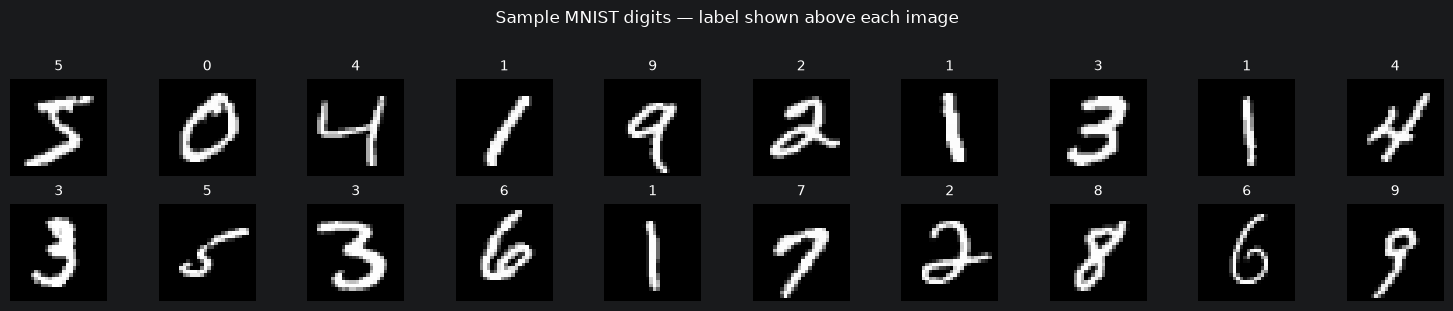

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(20):
    img, label = train_dataset[i]
    ax = axes[i // 10][i % 10]
    ax.imshow(img.squeeze(), cmap='gray')  # squeeze: (1,28,28) → (28,28) for display
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')

plt.suptitle('Sample MNIST digits — label shown above each image', y=1.02)
plt.tight_layout()
plt.show()



---
## Part 2: What is an Autoencoder?

An Autoencoder is a neural network trained to **compress** data into a small representation
and then **reconstruct** it back. It has three parts:

```
Input x  →  [Encoder fE]  →  Latent z  →  [Decoder fD]  →  Reconstruction x̂
  784              ↓              ↓               ↓               784
pixels          shrinks       bottleneck        expands          pixels
```

| Component | Role |
|-----------|------|
| Encoder `fE` | Maps x → z (compression) |
| Latent space z | Compressed representation — the bottleneck |
| Decoder `fD` | Maps z → x̂ (reconstruction) |

### Training objective 

The model minimises **reconstruction loss** — the squared difference between input and output:

$$\mathcal{L}_{AE} = ||\mathbf{x} - \hat{\mathbf{x}}||^2$$

There are **no labels** — the target IS the input itself. This is **unsupervised learning**.

### The bottleneck (latent dimension)

The bottleneck size controls how much compression happens:

| Latent dim | Effect |
|------------|--------|
| Too small (e.g. 2) | Model cannot store enough information → blurry reconstructions |
| Too large (e.g. 512) | Model memorises without learning useful features |
| Just right (e.g. 16–64) | Forces the model to learn the most important features |

### Applications
- **Dimensionality reduction** - similar to PCA but non-linear
- **Denoising** - remove noise from images
- **Anomaly detection** - high reconstruction error = anomaly
- **Representation learning** - the latent vector is a useful feature for downstream tasks


---
## Part 3: Building a Standard Autoencoder

Our MLP Autoencoder architecture:
```
Input (784)  →  256  →  64  →  latent_dim    [Encoder]
latent_dim   →  64   →  256 →  784  → Tanh   [Decoder]
```

We build the model in four separate steps so each piece is clear before we assemble them.


### Step 1 — Define the Encoder

The encoder is the **compression** half. It takes a flat 784-pixel vector and reduces it to
`latent_dim` numbers using two `Linear → ReLU` pairs.

Key points:
- `nn.Linear(784, 256)` — a fully-connected layer: 784 inputs, 256 outputs
- `nn.ReLU()` — the activation function applied after each linear layer
- The **final linear layer has no activation** — the latent values `z` can be any real number
- `x.view(-1, 784)` flattens the image: `(batch, 1, 28, 28)` → `(batch, 784)`


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # ── Encoder: 784 → 256 → 64 → latent_dim ──────────
        # Each Linear+ReLU pair halves the representation size.
        # The final layer has no activation — z values are unbounded real numbers.
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),  nn.ReLU(),   # 784 → 256
            nn.Linear(256,  64),  nn.ReLU(),   # 256 → 64
            nn.Linear( 64, latent_dim)          # 64  → z  (no activation)
        )
```


### Step 2 — Define the Decoder

The decoder is the **reconstruction** half. It mirrors the encoder and expands `z` back to 784 pixels.

Key points:
- The layer sizes are exactly the **reverse** of the encoder
- The final activation is `Tanh` (output range −1 to 1)
- We use `Tanh` — NOT `Sigmoid` — because we normalised pixels to (−1, 1) in Step 2 of Part 1.
  Using `Sigmoid` (range 0–1) here would give systematically wrong outputs.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
        # ── Decoder: latent_dim → 64 → 256 → 784 ───
        # Mirrors the encoder in reverse. Final Tanh matches the (-1,1) pixel range.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),   # z   → 64
            nn.Linear( 64, 256),        nn.ReLU(),   # 64  → 256
            nn.Linear(256, 784),                     # 256 → 784
            nn.Tanh()   # output in (-1,1) — matches our Normalize((0.5),(0.5)) preprocessing
        )
```


### Step 3 — Define `encode`, `decode`, and `forward`

These three methods define how data flows through the model:

| Method | Input | Output | What it does |
|--------|-------|--------|-------------|
| `encode(x)` | image `(batch,1,28,28)` | latent `(batch, latent_dim)` | Flattens image, runs encoder |
| `decode(z)` | latent `(batch, latent_dim)` | image `(batch,1,28,28)` | Runs decoder, reshapes to image |
| `forward(x)` | image | `(x̂, z)` | Calls encode then decode; returns both |

The `forward` method returns **both** the reconstruction `x̂` and the latent vector `z` — we will
need `z` when we visualise the latent space in Part 6.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    def encode(self, x):
        x = x.view(-1, 784)      # flatten: (batch,1,28,28) → (batch,784)
        return self.encoder(x)   # → (batch, latent_dim)

    def decode(self, z):
        out = self.decoder(z)               # → (batch, 784)
        return out.view(-1, 1, 28, 28)      # reshape: (batch,784) → (batch,1,28,28)

    def forward(self, x):
        z     = self.encode(x)   # compress to latent space
        x_hat = self.decode(z)   # reconstruct from latent space
        return x_hat, z          # return BOTH so we can inspect z later
```


### Step 4 — Instantiate the model and inspect it

Creating an instance of the class allocates all the weight tensors.
We send the model `.to(device)` so its parameters live on the same device as the data.

The parameter count tells us how complex the model is.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
ae = Autoencoder(latent_dim=16).to(device)
print(ae)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in ae.parameters()):,}")
print(f"Latent dimension           : {ae.latent_dim}")
print(f"Compression ratio          : 784 → {ae.latent_dim}  ({ae.latent_dim/784*100:.1f}% of original size)")
```


### the assembeled code is:

In [4]:
class Autoencoder(nn.Module):
    """
    MLP Autoencoder for MNIST.
    Encoder: 784 → 256 → 64 → latent_dim
    Decoder: latent_dim → 64 → 256 → 784
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder — progressively compresses the input
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)   # bottleneck — no activation
        )

        # Decoder — mirrors the encoder, expands back to 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()   # output in (-1, 1) to match normalised pixel range
        )

    def encode(self, x):
        """Flatten image and encode to latent vector."""
        x = x.view(-1, 784)   # (batch, 1, 28, 28) → (batch, 784)
        return self.encoder(x)

    def decode(self, z):
        """Decode latent vector and reshape to image."""
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)   # (batch, 784) → (batch, 1, 28, 28)

    def forward(self, x):
        z     = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z


ae = Autoencoder(latent_dim=16).to(device)
print(ae)
print(f"\nTotal parameters: {sum(p.numel() for p in ae.parameters()):,}")
print(f"Latent dimension: {ae.latent_dim}")
print(f"\nCompression ratio: 784 → {ae.latent_dim}  ({ae.latent_dim/784*100:.1f}% of original size)")


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total parameters: 437,664
Latent dimension: 16

Compression ratio: 784 → 16  (2.0% of original size)


---
## Part 4: Training the Autoencoder

The training loop uses the same five steps from Tutorial 1:
1. Forward pass
2. Compute loss
3. `zero_grad()`
4. `backward()`
5. `optimizer.step()`

**The only difference from Tutorial 1:** the loss target is the input itself, not a label.
```python
# Classification (Tutorial 1):   loss = criterion(output, label)
# Autoencoder   (this tutorial): loss = criterion(output, input)  ← target IS the input
```
We use `MSELoss`:
$$\mathcal{L}_{AE} = ||\mathbf{x} - \hat{\mathbf{x}}||^2$$


### Step 1 — Define the loss function and optimiser

`nn.MSELoss()` computes the average squared pixel difference across the whole batch.
Adam with learning rate 0.001 is a reliable default — same as Tutorial 1.


In [5]:
# These two lines are all the setup needed before the training loop.
criterion = nn.MSELoss()                            # MSE = mean squared pixel error
optimizer = optim.Adam(ae.parameters(), lr=1e-3)   # Adam, lr=0.001
print("Loss function :", criterion)
print("Optimiser     :", type(optimizer).__name__)


Loss function : MSELoss()
Optimiser     : Adam


### Step 2 — Write the training loop

Notice two important things:
1. `for imgs, _ in train_loader:` — the `_` discards the labels. We do not need them.
2. `loss = criterion(x_hat, imgs)` — the **target is `imgs`**, the same tensor we fed in.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
def train_autoencoder(model, train_loader, test_loader, epochs=20, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # ── Training phase ─────────────────────────────────────────────
        model.train()              # enables dropout/batchnorm if present
        running_loss = 0.0

        for imgs, _ in train_loader:    # _ = digit label — NOT needed
            imgs = imgs.to(device)

            x_hat, _ = model(imgs)          # Step 1: forward pass
            loss = criterion(x_hat, imgs)   # Step 2: loss — target IS the input!

            optimizer.zero_grad()           # Step 3: clear old gradients
            loss.backward()                 # Step 4: compute new gradients
            optimizer.step()                # Step 5: update weights
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))
```


### Step 3 — Add the validation phase

After each epoch we evaluate on the test set to check for overfitting.
We use `model.eval()` and `torch.no_grad()` for the same reasons as Tutorial 1:
- `model.eval()` disables dropout / batchnorm training behaviour
- `torch.no_grad()` saves memory — we do not need gradients during evaluation


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
        # ── Validation phase ───────────────────────────────────────────
        model.eval()           # disables dropout, batchnorm training mode
        val_loss = 0.0

        with torch.no_grad():  # no gradients needed → faster + less memory
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                x_hat, _ = model(imgs)
                val_loss += criterion(x_hat, imgs).item()

        val_losses.append(val_loss / len(test_loader))

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses
```


### Step 4 — Train the model

`torch.manual_seed(42)` ensures reproducibility - every run with the same seed produces
the same random weight initialisation.

You should see the loss steadily decrease. If train and val loss diverge, the model is overfitting.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
torch.manual_seed(42)
ae = Autoencoder(latent_dim=16).to(device)
ae_train_losses, ae_val_losses = train_autoencoder(ae, train_loader, test_loader, epochs=20)
```


### the assembeled code is:

In [6]:
def train_autoencoder(model, train_loader, test_loader, epochs=20, lr=1e-3):
    """
    Train an Autoencoder. Target = input (unsupervised).
    Returns training and validation loss history.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:        # _ = labels (not needed)
            imgs = imgs.to(device)

            x_hat, _ = model(imgs)          # forward pass
            loss = criterion(x_hat, imgs)   # target IS the input

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ── Validation ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                x_hat, _ = model(imgs)
                val_loss += criterion(x_hat, imgs).item()
        val_loss /= len(test_loader)
        val_losses.append(val_loss)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses


torch.manual_seed(42)
ae = Autoencoder(latent_dim=16).to(device)
ae_train_losses, ae_val_losses = train_autoencoder(ae, train_loader, test_loader, epochs=20)


Epoch   1/20 | Train Loss: 0.1635 | Val Loss: 0.0938
Epoch   6/20 | Train Loss: 0.0550 | Val Loss: 0.0531
Epoch  11/20 | Train Loss: 0.0473 | Val Loss: 0.0464
Epoch  16/20 | Train Loss: 0.0436 | Val Loss: 0.0431
Epoch  20/20 | Train Loss: 0.0418 | Val Loss: 0.0418


### Step 5 — Plot the loss curves

training curve shows both losses decreasing and staying close together.
If the validation loss stops decreasing while training loss keeps falling, the model is overfitting.


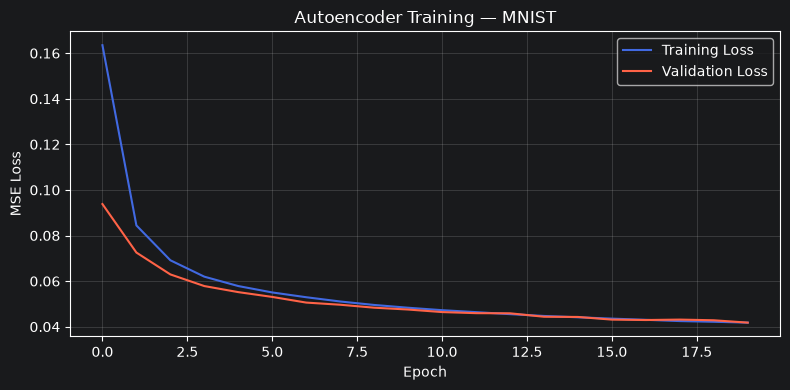

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(ae_train_losses, color='royalblue', label='Training Loss')
plt.plot(ae_val_losses,   color='tomato',    label='Validation Loss')
plt.title('Autoencoder Training — MNIST')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 5: Visualising Reconstructions

After training we compare the **original** images (top row) with the **reconstructed** images
(bottom row). Good reconstructions mean the model has learned a useful latent representation.

If reconstructions are blurry or wrong, the latent dimension may be too small, or training needs more epochs.


### Step 1 — Define a reusable helper function

This helper handles the boilerplate of encoding a batch, decoding it, and plotting side by side.
We call it with different models later (AE vs VAE) so we only write the plot code once.


In [8]:
def show_reconstructions(model, dataset, n=10, title="Reconstructions"):
    """Display original images (top row) vs reconstructions (bottom row)."""
    model.eval()

    # Grab n images from the dataset and stack them into a batch
    imgs = torch.stack([dataset[i][0] for i in range(n)]).to(device)

    with torch.no_grad():
        recons, _ = model(imgs)   # forward pass - recons has same shape as imgs

    # Plot
    fig, axes = plt.subplots(2, n, figsize=(15, 3))
    for i in range(n):
        axes[0, i].imshow(imgs[i].cpu().squeeze(),   cmap='gray')  # original
        axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')  # reconstruction
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original',      fontsize=10)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


### Step 2 — Run the helper on the test set

The test set images were never seen during training  - this is a fair check of quality.


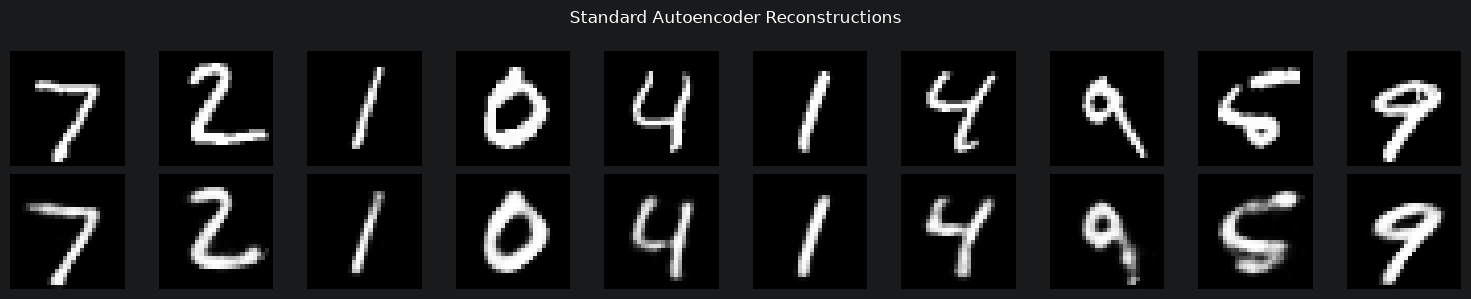

Top row: original digits from the test set.
Bottom row: what the Autoencoder produces after compressing to 16 numbers and expanding back.


In [9]:
show_reconstructions(ae, test_dataset, n=10, title="Standard Autoencoder Reconstructions")
print("Top row: original digits from the test set.")
print("Bottom row: what the Autoencoder produces after compressing to 16 numbers and expanding back.")


---
## Part 6: Visualising the Latent Space

To see what the Autoencoder has learned, we can plot where each image ends up in latent space.
With `latent_dim=16` we would need dimensionality reduction (like t-SNE) to visualise it.
Instead, we train a simpler model with `latent_dim=2` so we can plot the two dimensions directly.

A **well-structured** latent space shows clusters — similar digits grouped together.
A **scattered** latent space means the model has not learned useful structure.


### Step 1 — Train a 2D Autoencoder

We use `latent_dim=2` so the entire latent space fits on a 2D scatter plot.
The reconstruction quality will be worse than with 16 dimensions (more compression = more loss),
but the latent space will be directly interpretable.


In [10]:
# Train a 2D Autoencoder
torch.manual_seed(42)
ae_2d = Autoencoder(latent_dim=2).to(device)
ae_2d_train, ae_2d_val = train_autoencoder(ae_2d, train_loader, test_loader, epochs=20)
print("\n2D Autoencoder trained.")

# Save weights so Part 14 can load them 
torch.save(ae_2d.state_dict(), 'ae_2d_mnist.pth')
print("Weights saved to ae_2d_mnist.pth ")


Epoch   1/20 | Train Loss: 0.2301 | Val Loss: 0.1929
Epoch   6/20 | Train Loss: 0.1617 | Val Loss: 0.1609
Epoch  11/20 | Train Loss: 0.1531 | Val Loss: 0.1542
Epoch  16/20 | Train Loss: 0.1489 | Val Loss: 0.1489
Epoch  20/20 | Train Loss: 0.1464 | Val Loss: 0.1464

2D Autoencoder trained.
Weights saved to ae_2d_mnist.pth 


### Step 2 — Encode the entire test set

We pass every test image through the encoder and collect the 2D latent vectors `z`
along with the true digit labels (used only for colouring - not for training).


In [11]:
ae_2d.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        _, z = ae_2d(imgs)               # encode: _ = reconstruction (not needed here), z = latent
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

# Stack all batches into single arrays
all_z      = np.concatenate(all_z,      axis=0)   # shape: (10000, 2)
all_labels = np.concatenate(all_labels, axis=0)   # shape: (10000,)

print(f"Encoded {len(all_z):,} test images into 2D latent vectors.")
print(f"Latent vector range: z1=[{all_z[:,0].min():.2f}, {all_z[:,0].max():.2f}]  "
      f"z2=[{all_z[:,1].min():.2f}, {all_z[:,1].max():.2f}]")


Encoded 10,000 test images into 2D latent vectors.
Latent vector range: z1=[-40.46, 33.68]  z2=[-23.95, 39.47]


### Step 3 — Scatter plot: one point per image, coloured by digit class

Each of the 10,000 points is one test image.
Its position on the plot is where the encoder placed it in latent space.
The colour shows which digit it actually is (0–9).

**What to look for:**
- Are digits of the same class (same colour) grouped together?
- Are the clusters well-separated from each other?
- Are there large empty regions between clusters?  ← this is a problem for generation


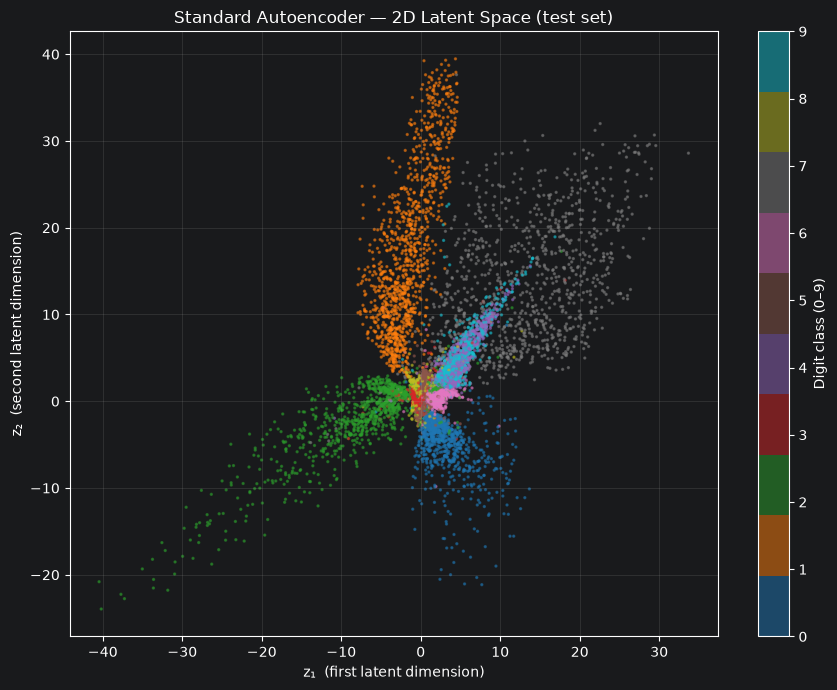

Observation: Are the clusters well-separated and evenly spread,
or irregular and scattered with large empty regions between them?
We will compare this with the VAE latent space in Part 14.


In [12]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1],
                      c=all_labels, cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, label='Digit class (0–9)')
plt.title('Standard Autoencoder — 2D Latent Space (test set)')
plt.xlabel('z₁  (first latent dimension)')
plt.ylabel('z₂  (second latent dimension)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Observation: Are the clusters well-separated and evenly spread,")
print("or irregular and scattered with large empty regions between them?")
print("We will compare this with the VAE latent space in Part 14.")


---
## Part 7: Why is a Standard Autoencoder Bad at Generation?

The standard Autoencoder has one serious limitation: **its latent space is not structured for sampling**.

### The problem with random sampling

The decoder only ever sees latent vectors that came from real training images. It has never seen a randomly sampled point. If you pick a random point in latent space, it very likely falls in an **empty region** that the decoder has never encountered so the output will be meaningless noise.



**Let's demonstrate this with two comparisons below.**

### Step 1 — Random sampling from N(0,1): what does the AE produce?

We sample 10 random latent vectors from a standard Gaussian N(0,1) and decode each one.
Because the AE's latent space is unstructured, most of these points land in "ocean" regions
the decoder has never seen - the output will typically be noise or blurry blobs.


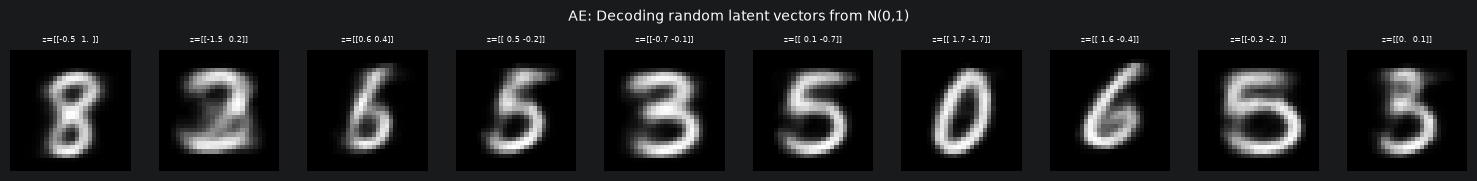

Most outputs look like noise or meaningless blobs — the latent space has 'holes'.


In [13]:
ae_2d.eval()

fig, axes = plt.subplots(1, 10, figsize=(15, 1.8))
fig.suptitle('AE: Decoding random latent vectors from N(0,1)', fontsize=10)

with torch.no_grad():
    for i in range(10):
        z_random = torch.randn(1, 2).to(device)   # random point — likely in "ocean"
        generated = ae_2d.decode(z_random)
        axes[i].imshow(generated.cpu().squeeze(), cmap='gray')
        axes[i].set_title(f'z={z_random.cpu().numpy().round(1)}', fontsize=6)
        axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Most outputs look like noise or meaningless blobs — the latent space has 'holes'.")


### Step 2 — Encoding real images: what does the AE produce?

For comparison, we encode 10 real images (going through the encoder) and decode them.
These latent vectors are on the "islands" the decoder knows - reconstructions are clear.

This contrast shows exactly why a structured latent space is needed for generation.


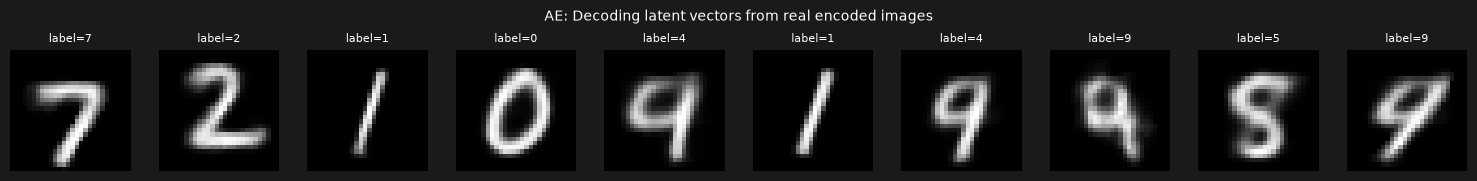

Reconstructions from real encoded images are clear — the latent vector is on an 'island'.

Conclusion: the AE can reconstruct well, but cannot generate new images by sampling.


In [14]:
fig, axes = plt.subplots(1, 10, figsize=(15, 1.8))
fig.suptitle('AE: Decoding latent vectors from real encoded images', fontsize=10)

with torch.no_grad():
    for i in range(10):
        img, label = test_dataset[i]
        img = img.unsqueeze(0).to(device)   # add batch dimension: (1,28,28) → (1,1,28,28)
        _, z = ae_2d(img)                   # encode the real image
        recon = ae_2d.decode(z)             # decode from its real latent vector
        axes[i].imshow(recon.cpu().squeeze(), cmap='gray')
        axes[i].set_title(f'label={label}', fontsize=8)
        axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Reconstructions from real encoded images are clear — the latent vector is on an 'island'.")
print("\nConclusion: the AE can reconstruct well, but cannot generate new images by sampling.")


---
###  Exercise 1 — Explore the Standard Autoencoder

1. Train an Autoencoder with `latent_dim=2` and one with `latent_dim=64`. Compare the final validation losses. What is the trade-off between compression and quality?
2. In the random sampling cell above, change `torch.randn` to `torch.zeros` (i.e. always sample the centre of the latent space). Does the output improve? Why or why not?
3. In one sentence: why can we not simply "fix" the standard Autoencoder by also training it on randomly sampled latent vectors?


---
## Part 8: Variational Autoencoder (VAE) 



The ideal latent space for generation has four properties:
1. **Smoothness** - nearby points decode to similar images
2. **Continuity** - no large empty gaps between regions
3. **Meaningful sampling** - random samples produce realistic outputs
4. **Interpolation capacity** - moving between two points produces gradual transitions

The VAE achieves all four by making the latent space **probabilistic**.

### Key idea: encode a distribution, not a point

Instead of mapping each input to a **single point** z, the VAE encoder predicts a
**probability distribution** — specifically a Gaussian:

$$\mathbf{z}_i \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\sigma}^2)$$

The encoder outputs **two** vectors for each input:
- **μ (mu)** — the mean (centre) of the distribution
- **log σ² (log_var)** — the log variance (width) of the distribution

> **Why log σ² and not σ² directly?**
> Variance must always be positive. If the network predicted σ² directly, it could output a negative
> number. Predicting log σ² (which can be any real number) and then applying `exp()` guarantees positivity.

### The Reparameterisation Trick 

We cannot backpropagate through a random sampling operation — sampling has no gradient.
The trick reformulates sampling so the randomness is **isolated in a constant ε**:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, I)$$

- ε is sampled from a fixed standard Gaussian — **not a learnable parameter**, no gradient needed
- Gradients flow through μ and σ normally — the model is fully trainable
- Stochasticity (randomness) is isolated in ε

### VAE Loss Function 

The VAE optimises two objectives simultaneously:

$$\mathcal{L}_{VAE} = \underbrace{||\mathbf{x} - \hat{\mathbf{x}}||^2}_{\text{Reconstruction Loss}} + \beta \cdot \underbrace{D_{KL}\left(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p(\mathbf{z})\right)}_{\text{KL Divergence}}$$

| Loss term | What it does | Effect if removed |
|-----------|-------------|-------------------|
| Reconstruction loss | Output must match input | Good quality reconstructions |
| KL divergence | Latent distribution must stay close to N(0,I) | Structured, sampleable latent space |

The KL divergence has a closed-form solution for Gaussian distributions:
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**β** controls the strength of regularisation. β=1 is the standard VAE; β>1 pushes harder toward N(0,I).

| Model | Standard AE | VAE |
|-------|-------------|-----|
| Encoder output | Single point z | μ and log σ² |
| Sampling | Deterministic | z = μ + σ·ε |
| Latent structure | Irregular | Regularised toward N(0,I) |
| Generation | Poor | Good |


---
## Part 9: Building the VAE

The VAE is very similar to the standard Autoencoder with **two critical differences**:
1. The encoder has **two output heads** (μ and log σ²) instead of one (z)
2. A `reparameterise` method samples z = μ + σ·ε during training

### **We build it step by step and then assemble everything into one complete working model.**



### Step 1 — Define the shared encoder body

The encoder body is the same MLP as the standard AE encoder, **except** it stops one layer earlier —
its output (shape `(batch, 64)`) feeds into the two separate heads defined in Step 2.

The shared body extracts features from the image; the two heads then interpret those features
as the parameters of a Gaussian distribution.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # ── Shared encoder body: 784 → 256 → 64 ─────────────────────
        # Same as standard AE encoder but stops at 64 units.
        # The 64-unit output feeds into BOTH heads below.
        self.encoder_body = nn.Sequential(
            nn.Linear(784, 256),  nn.ReLU(),   # 784 → 256
            nn.Linear(256,  64),  nn.ReLU()    # 256 → 64  (feeds two heads)
        )
```


### Step 2 — Define the two output heads: μ and log σ²

This is the **defining difference** between the standard AE and the VAE encoder.

Instead of one output:
```python
self.fc_z = nn.Linear(64, latent_dim)       # standard AE: outputs z directly
```

The VAE has two:
```python
self.fc_mu      = nn.Linear(64, latent_dim)   # VAE head 1: outputs μ (mean)
self.fc_log_var = nn.Linear(64, latent_dim)   # VAE head 2: outputs log σ²
```

Both heads take the same 64-unit input - they are two separate linear projections of
the same learned features.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
        # ── Two output heads — the key difference from standard AE ──────
        # Same input (64 units from encoder_body), separate learnable projections.
        self.fc_mu      = nn.Linear(64, latent_dim)   # → mean μ of shape (batch, latent_dim)
        self.fc_log_var = nn.Linear(64, latent_dim)   # → log σ²  (any real number → always pos after exp)
```


### Step 3 — Define the Decoder

The VAE decoder is **identical** to the standard AE decoder.
The only difference is what goes in: z now comes from sampling (μ + σ·ε) rather than directly from the encoder.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
        # ── Decoder: latent_dim → 64 → 256 → 784 ───────────────────────
        # Identical to the standard AE decoder.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear( 64, 256),        nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()   # output in (-1,1) — matches normalised pixels
        )
```


### Step 4 — Define the `encode` method

The VAE `encode` returns **two** tensors instead of one:
- `mu` — the predicted mean for each image, shape `(batch, latent_dim)`
- `log_var` — the predicted log variance, shape `(batch, latent_dim)`

Together they define a Gaussian distribution: `z ~ N(mu, exp(log_var))`.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    def encode(self, x):
        """Returns (mu, log_var) — the parameters of the latent Gaussian distribution."""
        x  = x.view(-1, 784)          # flatten: (batch,1,28,28) → (batch,784)
        h  = self.encoder_body(x)     # shared features → (batch,64)
        mu      = self.fc_mu(h)       # mean      → (batch, latent_dim)
        log_var = self.fc_log_var(h)  # log var   → (batch, latent_dim)
        return mu, log_var
```


### Step 5 — Define `reparameterise`: the core trick

This is the most important method in the VAE.

**The problem:** we need to sample z ~ N(μ, σ²), but sampling is not differentiable — gradients cannot flow through it.

**The trick:** rewrite the sample as:
```
z = μ + σ · ε       where ε ~ N(0,I)
```
- ε is random noise drawn from a fixed standard Gaussian — it is **not part of the computation graph**
- μ and σ = exp(0.5 · log σ²) are outputs of the network — **gradients flow through them normally**
- At inference time (`.eval()`), we skip the noise and just use μ — this gives deterministic reconstructions

The `torch.randn_like(std)` call is important: it creates noise with the **same shape and on the same device** as `std`, avoiding device mismatch errors on GPU.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    def reparameterise(self, mu, log_var):
        """
        Reparameterisation trick: z = mu + std * eps,  eps ~ N(0,I)
        During training: sample with noise → regularises the latent space
        During eval:     return mu only   → deterministic, reproducible
        """
        if self.training:
            std = torch.exp(0.5 * log_var)   # std = sqrt(var) = exp(0.5 * log σ²)
            eps = torch.randn_like(std)       # ε ~ N(0,I), same device and shape as std
            return mu + std * eps             # z = μ + σ·ε  (the reparameterisation)
        else:
            return mu   # at inference: use mean directly — no randomness needed
```


### Step 6 — Define `decode` and `forward`, then instantiate

`forward` now returns **three** things: reconstruction `x̂`, mean `mu`, and log variance `log_var`.
We need `mu` and `log_var` to compute the KL divergence loss in Part 10.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)  # (batch,784) → (batch,1,28,28)

    def forward(self, x):
        mu, log_var = self.encode(x)          # encoder → (mu, log_var)
        z           = self.reparameterise(mu, log_var)  # sample z
        x_hat       = self.decode(z)          # decoder → reconstruction
        return x_hat, mu, log_var             # return all three — need mu & log_var for KL loss


# ── Instantiate and inspect ───────────────────────────────────────────
vae = VAE(latent_dim=16).to(device)
print(vae)
print(f"\nTotal parameters : {sum(p.numel() for p in vae.parameters()):,}")
print(f"\nEncoder outputs  : mu of shape (batch, {vae.latent_dim})")
print(f"                   log_var of shape (batch, {vae.latent_dim})")
print(f"Decoder input    : z of shape (batch, {vae.latent_dim})")
```


### the assembeled code is:

In [15]:
class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST.

    Encoder: 784 → 256 → 64 → (μ, log σ²)   [two separate output heads]
    Decoder: z → 64 → 256 → 784

    Key difference from standard AE:
      - Encoder outputs TWO vectors: mu and log_var
      - Latent z is sampled using the reparameterisation trick: z = mu + std * eps
      - Training uses both reconstruction loss AND KL divergence
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # ── Shared encoder body ────
        self.encoder_body = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # ── Two separate output heads ───
        self.fc_mu      = nn.Linear(64, latent_dim)   # predicts mean μ
        self.fc_log_var = nn.Linear(64, latent_dim)   # predicts log σ²

        # ── Decoder (same as standard AE) ───
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def encode(self, x):
        """Returns mu and log_var for the input batch."""
        x = x.view(-1, 784)
        h = self.encoder_body(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterise(self, mu, log_var):
        """
        Reparameterisation trick: z = mu + std * eps
        eps ~ N(0, I)  — random noise, not a learnable parameter
        std = exp(0.5 * log_var)  — converts log variance back to std deviation
        """
        if self.training:
            std = torch.exp(0.5 * log_var)   # std = sqrt(variance) = exp(0.5 * log σ²)
            eps = torch.randn_like(std)       # eps ~ N(0, I), same shape as std
            return mu + std * eps             # z = mu + std * eps
        else:
            return mu   # at inference time, just use the mean (no randomness needed)

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z     = self.reparameterise(mu, log_var)
        x_hat = self.decode(z)
        return x_hat, mu, log_var


vae = VAE(latent_dim=16).to(device)
print(vae)
print(f"\nTotal parameters: {sum(p.numel() for p in vae.parameters()):,}")
print(f"\nEncoder outputs  : mu of shape (batch, {vae.latent_dim})")
print(f"                   log_var of shape (batch, {vae.latent_dim})")
print(f"Decoder input    : z of shape (batch, {vae.latent_dim})")


VAE(
  (encoder_body): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_log_var): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total parameters: 438,704

Encoder outputs  : mu of shape (batch, 16)
                   log_var of shape (batch, 16)
Decoder input    : z of shape (batch, 16)


---
## Part 10: The VAE Loss Function

The VAE loss has two components:

**1. Reconstruction Loss** — same MSE as the standard Autoencoder:
$$\mathcal{L}_{recon} = ||\mathbf{x} - \hat{\mathbf{x}}||^2$$

**2. KL Divergence** — measures how far the learned distribution is from N(0,I).  
For a Gaussian encoder the KL has a closed-form solution:
$$\mathcal{L}_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

In PyTorch with `log_var = log σ²` already computed by the encoder:
```python
kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
```

**β-VAE**: In practice a weighting factor β scales the KL term:
$$\mathcal{L}_{VAE} = \mathcal{L}_{recon} + \beta \cdot \mathcal{L}_{KL}$$

- β = 1: standard VAE
- β > 1: stronger regularisation → better generation, worse reconstruction
- β < 1: weaker regularisation → better reconstruction, worse generation


### Step 1 — Implement the reconstruction loss

We use `mse_loss` with `reduction='sum'` and then divide by batch size.
This gives a per-sample average that is comparable across different batch sizes.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    """
    VAE total loss = Reconstruction loss + beta * KL divergence.
    Returns (total_loss, recon_loss, kl_loss) as separate scalars for monitoring.
    """
    # ── Reconstruction loss ───────────────────────────────────────────
    # sum over all pixels, then average over the batch
    recon_loss = nn.functional.mse_loss(x_hat, x, reduction='sum') / x.size(0)
```


### Step 2 — Implement the KL divergence

`torch.sum` sums over the `latent_dim` dimensions.
Dividing by `x.size(0)` gives the per-sample average.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    # ── KL divergence ────────────────────────────────────────────────
    # Closed-form KL between the encoder's Gaussian and N(0,I):
    # KL = -0.5 * sum(1 + log_var - mu² - exp(log_var))
    # This penalises: mu far from 0, and log_var far from 0 (i.e. std far from 1)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var)) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss
```


### Step 3 — Sanity check before training

Before training, the model weights are random. The KL should be near 0
(because random weights produce mu ≈ 0, log_var ≈ 0 which is already close to N(0,I)).
The reconstruction loss will be high because the model has not learned anything yet.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
vae.eval()
sample_imgs = torch.stack([test_dataset[i][0] for i in range(8)]).to(device)

with torch.no_grad():
    x_hat, mu, log_var = vae(sample_imgs)

total, recon, kl = vae_loss(sample_imgs, x_hat, mu, log_var)
print("Before training (random weights):")
print(f"  Reconstruction loss : {recon.item():.4f}  ← high because model has not learned yet")
print(f"  KL divergence       : {kl.item():.4f}   ← near 0: random weights ≈ N(0,I)")
print(f"  Total VAE loss      : {total.item():.4f}")
```


### the assembeled code is:

In [16]:
def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    """
    VAE loss = Reconstruction loss + beta * KL divergence.

    Args:
        x       : original input images  (batch, 1, 28, 28)
        x_hat   : reconstructed images   (batch, 1, 28, 28)
        mu      : encoder mean           (batch, latent_dim)
        log_var : encoder log variance   (batch, latent_dim)
        beta    : KL weight (default 1.0 = standard VAE)

    Returns:
        total_loss, recon_loss, kl_loss  — all as scalar tensors
    """
    # Reconstruction loss — same as standard AE
    # reduction='sum' then divide by batch size gives per-sample average
    recon_loss = nn.functional.mse_loss(x_hat, x, reduction='sum') / x.size(0)

    # KL divergence — closed-form for Gaussian encoder
    # = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # sum over latent dimensions, mean over batch
    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var)) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


# ── Quick sanity check ───
vae.eval()
sample_imgs = torch.stack([test_dataset[i][0] for i in range(8)]).to(device)
with torch.no_grad():
    x_hat, mu, log_var = vae(sample_imgs)

total, recon, kl = vae_loss(sample_imgs, x_hat, mu, log_var)
print(f"Before training:")
print(f"  Reconstruction loss : {recon.item():.4f}")
print(f"  KL divergence       : {kl.item():.4f}")
print(f"  Total VAE loss      : {total.item():.4f}")
print("\n(KL is near 0 before training because log_var starts near 0 and mu near 0)")


Before training:
  Reconstruction loss : 731.4906
  KL divergence       : 0.1557
  Total VAE loss      : 731.6462

(KL is near 0 before training because log_var starts near 0 and mu near 0)


---
## Part 11: Training the VAE

The training loop is structurally identical to the standard AE training loop from Part 4.
The only changes are:
1. The model returns `(x_hat, mu, log_var)` instead of `(x_hat, z)`
2. The loss is `vae_loss(...)` instead of `MSELoss`
3. We track three loss quantities (total, reconstruction, KL) instead of one


### Step 1 — Set up optimiser and history dictionary

We record six quantities per epoch - three for training and three for validation -
so we can plot each component of the loss separately and understand what the model is learning.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, beta=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track total loss, reconstruction loss, and KL divergence separately
    history = {k: [] for k in
               ['train_total', 'train_recon', 'train_kl',
                'val_total',   'val_recon',   'val_kl']}
```


### Step 2 — Training step


- Model returns three values: `x_hat, mu, log_var`
- Loss comes from `vae_loss(...)` which returns three separate components


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
    for epoch in range(epochs):
        # ── Training phase ─────────────────────────────────────────────
        model.train()
        t_total = t_recon = t_kl = 0.0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)

            x_hat, mu, log_var = model(imgs)                           # forward: 3 outputs
            loss, recon, kl    = vae_loss(imgs, x_hat, mu, log_var, beta=beta)  # 3 losses

            optimizer.zero_grad()
            loss.backward()   # gradients flow through mu and log_var via reparameterisation
            optimizer.step()

            t_total += loss.item()
            t_recon += recon.item()
            t_kl    += kl.item()

        n = len(train_loader)
        history['train_total'].append(t_total / n)
        history['train_recon'].append(t_recon / n)
        history['train_kl'].append(t_kl    / n)
```


### Step 3 — Validation step

Same structure as the training step but with `model.eval()` and `torch.no_grad()`.
Note: in eval mode, `reparameterise` returns `mu` (not a sample) - reconstructions are deterministic.


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
        # ── Validation phase ───────────────────────────────────────────
        model.eval()
        v_total = v_recon = v_kl = 0.0

        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                x_hat, mu, log_var = model(imgs)
                loss, recon, kl    = vae_loss(imgs, x_hat, mu, log_var, beta=beta)
                v_total += loss.item()
                v_recon += recon.item()
                v_kl    += kl.item()

        nv = len(test_loader)
        history['val_total'].append(v_total / nv)
        history['val_recon'].append(v_recon / nv)
        history['val_kl'].append(v_kl    / nv)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train: {t_total/n:.3f}  "
                  f"(Recon {t_recon/n:.3f}, KL {t_kl/n:.3f}) | "
                  f"Val: {v_total/nv:.3f}")

    return history
```


### Step 4 — Run training and observe the loss components

Watch how each component evolves:
- **Reconstruction loss** should decrease - the model learns to reconstruct images
- **KL divergence** starts near 0 and **rises** as the encoder spreads latent codes across more of the space
- This rise in KL is healthy and expected - it means the VAE is learning a structured latent space


> **Code fragment:** This is part of the assembled implementation below and is not run separately.

```python
torch.manual_seed(42)
vae = VAE(latent_dim=16).to(device)
vae_history = train_vae(vae, train_loader, test_loader, epochs=20, beta=1.0)
```


### the assembeled code is:

In [17]:
def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, beta=1.0):
    """
    Train a VAE. Returns history of total, reconstruction, and KL losses.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_total': [], 'train_recon': [], 'train_kl': [],
               'val_total':   [], 'val_recon':   [], 'val_kl':   []}

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        t_total = t_recon = t_kl = 0.0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            x_hat, mu, log_var = model(imgs)
            loss, recon, kl = vae_loss(imgs, x_hat, mu, log_var, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t_total += loss.item()
            t_recon += recon.item()
            t_kl    += kl.item()

        n = len(train_loader)
        history['train_total'].append(t_total / n)
        history['train_recon'].append(t_recon / n)
        history['train_kl'].append(t_kl / n)

        # ── Validation ──
        model.eval()
        v_total = v_recon = v_kl = 0.0
        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                x_hat, mu, log_var = model(imgs)
                loss, recon, kl = vae_loss(imgs, x_hat, mu, log_var, beta=beta)
                v_total += loss.item()
                v_recon += recon.item()
                v_kl    += kl.item()

        nv = len(test_loader)
        history['val_total'].append(v_total / nv)
        history['val_recon'].append(v_recon / nv)
        history['val_kl'].append(v_kl / nv)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {t_total/n:.3f} (Recon: {t_recon/n:.3f}, KL: {t_kl/n:.3f}) | "
                  f"Val Loss: {v_total/nv:.3f}")

    return history


torch.manual_seed(42)
vae = VAE(latent_dim=16).to(device)
vae_history = train_vae(vae, train_loader, test_loader, epochs=20, beta=1.0)


Epoch   1/20 | Train Loss: 168.098 (Recon: 157.146, KL: 10.952) | Val Loss: 113.744
Epoch   6/20 | Train Loss: 79.683 (Recon: 58.464, KL: 21.219) | Val Loss: 71.585
Epoch  11/20 | Train Loss: 73.439 (Recon: 51.385, KL: 22.054) | Val Loss: 66.877
Epoch  16/20 | Train Loss: 70.699 (Recon: 48.307, KL: 22.393) | Val Loss: 64.296
Epoch  20/20 | Train Loss: 69.366 (Recon: 46.811, KL: 22.555) | Val Loss: 62.747


### Step 5 — Plot all three loss curves separately

Plotting the three curves separately lets you see the tension between reconstruction and regularisation.


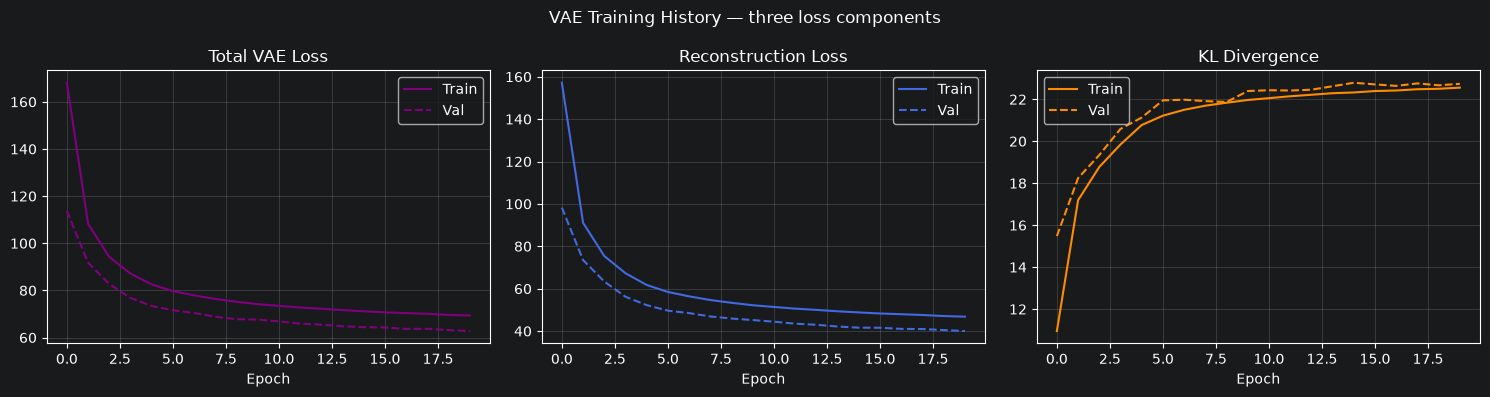

Expected pattern:
  Reconstruction loss → decreases (model learns to reconstruct)
  KL divergence       → starts near 0 and rises (latent space spreads toward N(0,I))
  Total loss          → decreases overall


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title, colour in zip(
    axes,
    ['total', 'recon', 'kl'],
    ['Total VAE Loss', 'Reconstruction Loss', 'KL Divergence'],
    ['purple', 'royalblue', 'darkorange']
):
    ax.plot(vae_history[f'train_{key}'], color=colour,                   label='Train')
    ax.plot(vae_history[f'val_{key}'],   color=colour, linestyle='--',  label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('VAE Training History — three loss components')
plt.tight_layout()
plt.show()

print("Expected pattern:")
print("  Reconstruction loss → decreases (model learns to reconstruct)")
print("  KL divergence       → starts near 0 and rises (latent space spreads toward N(0,I))")
print("  Total loss          → decreases overall")


---
## Part 12: Comparing AE and VAE Reconstructions

VAE reconstructions are typically slightly **blurrier** than AE reconstructions.
This is expected: the reparameterisation adds noise during training, which acts as a regulariser
and prevents the model from memorising exact pixel values.

The trade-off is: less sharpness, but a much better latent space for generation.


### Step 1 — Run both models on the same 10 test images


In [19]:
ae.eval()
vae.eval()

imgs = torch.stack([test_dataset[i][0] for i in range(10)]).to(device)

with torch.no_grad():
    ae_recons,  _         = ae(imgs)           # AE: returns (x_hat, z)
    vae_recons, mu, lv    = vae(imgs)          # VAE: returns (x_hat, mu, log_var)

print("AE  reconstructions shape:", ae_recons.shape)
print("VAE reconstructions shape:", vae_recons.shape)


AE  reconstructions shape: torch.Size([10, 1, 28, 28])
VAE reconstructions shape: torch.Size([10, 1, 28, 28])


### Step 2 — Display all three rows side by side

- Row 1: original test images
- Row 2: standard AE reconstructions
- Row 3: VAE reconstructions


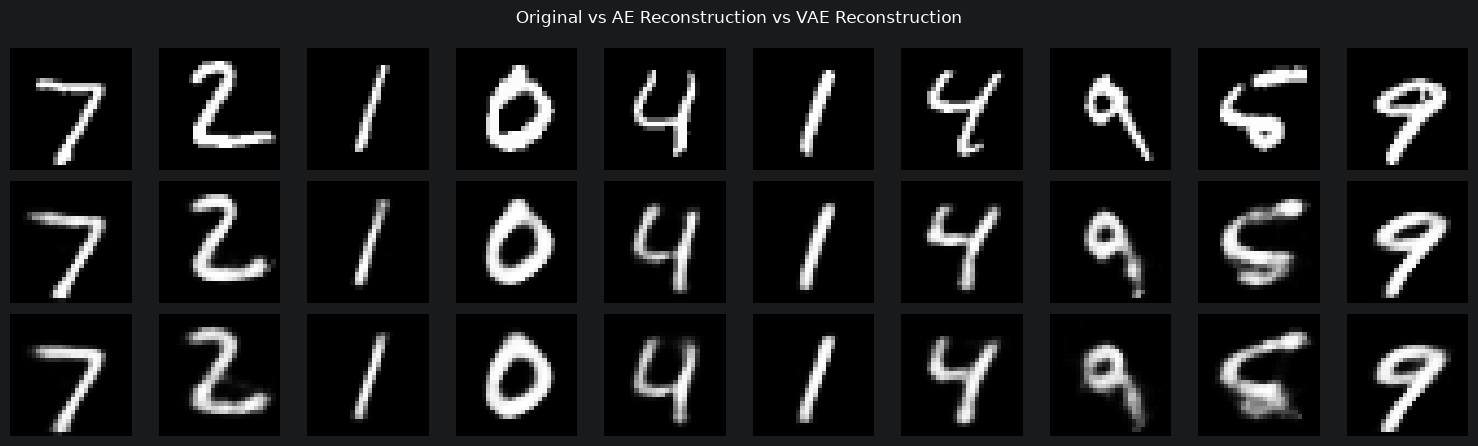

AE reconstructions tend to be sharper.
VAE reconstructions may be slightly blurrier — this is the regularisation effect.


In [20]:
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
row_labels = ['Original', 'AE Recon', 'VAE Recon']
row_data   = [imgs, ae_recons, vae_recons]

for row, (row_imgs, label) in enumerate(zip(row_data, row_labels)):
    for i in range(10):
        axes[row, i].imshow(row_imgs[i].cpu().squeeze(), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle('Original vs AE Reconstruction vs VAE Reconstruction')
plt.tight_layout()
plt.show()

print("AE reconstructions tend to be sharper.")
print("VAE reconstructions may be slightly blurrier — this is the regularisation effect.")


---
## Part 13: Generating New Images by Sampling

This is where the VAE truly outperforms the standard Autoencoder.

Because the KL divergence regularises the latent space toward **N(0,I)**, we can:
1. Sample a random vector z ~ N(0,I)
2. Pass it through the decoder
3. Get a **new, plausible digit** - not noise

This is the whole point of the VAE - it is a **generative model**.


### Step 1 — Sample random latent vectors

We sample 20 vectors from the standard Gaussian N(0,I) using `torch.randn`.
Each vector has `latent_dim=16` dimensions.


In [21]:
vae.eval()

n_samples = 20
with torch.no_grad():
    # Sample z ~ N(0,I) — this is where generation starts
    z_samples = torch.randn(n_samples, vae.latent_dim).to(device)
    print(f"Sampled {n_samples} latent vectors, each of dimension {vae.latent_dim}")
    print(f"z_samples shape: {z_samples.shape}")
    print(f"z_samples range: [{z_samples.min():.2f}, {z_samples.max():.2f}]")


Sampled 20 latent vectors, each of dimension 16
z_samples shape: torch.Size([20, 16])
z_samples range: [-3.28, 3.67]


### Step 2 — Decode each sample and display

We call `vae.decode(z_samples)` directly - no encoder is involved.
The decoder maps each 16-dimensional random vector to a 28×28 image.


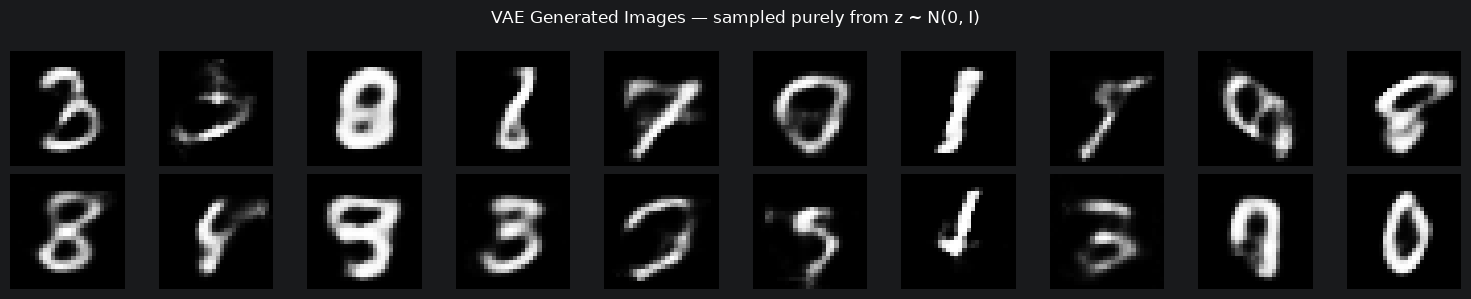

These images were generated from random noise — no real digit was used as input.
Compare this to Part 7 where random sampling in the standard AE produced only noise.


In [22]:
with torch.no_grad():
    generated = vae.decode(z_samples)   # decoder maps z → x̂  (no encoder needed)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(n_samples):
    ax = axes[i // 10][i % 10]
    ax.imshow(generated[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('VAE Generated Images — sampled purely from z ~ N(0, I)')
plt.tight_layout()
plt.show()

print("These images were generated from random noise — no real digit was used as input.")
print("Compare this to Part 7 where random sampling in the standard AE produced only noise.")


---
## Part 14: VAE Latent Space — Comparing with the Standard AE

We train a 2D VAE (same as the 2D AE in Part 6) so we can directly compare their latent spaces
on the same scale.

A well-trained VAE latent space should be:
- **Centred around 0** — the KL pushes the distribution toward N(0,I)
- **Continuous** — no large empty gaps; nearby points decode to similar images
- **Smooth** — digit clusters overlap and blend rather than sitting as isolated islands


### Step 1 — Train a 2D VAE


In [23]:
torch.manual_seed(42)
vae_2d = VAE(latent_dim=2).to(device)
vae_2d_history = train_vae(vae_2d, train_loader, test_loader, epochs=20, beta=1.0)
print("\n2D VAE trained - ready to visualise latent space.")


Epoch   1/20 | Train Loss: 183.502 (Recon: 178.411, KL: 5.091) | Val Loss: 152.367
Epoch   6/20 | Train Loss: 133.703 (Recon: 127.402, KL: 6.301) | Val Loss: 130.949
Epoch  11/20 | Train Loss: 128.007 (Recon: 121.427, KL: 6.580) | Val Loss: 126.297
Epoch  16/20 | Train Loss: 125.122 (Recon: 118.407, KL: 6.715) | Val Loss: 123.910
Epoch  20/20 | Train Loss: 123.829 (Recon: 117.063, KL: 6.766) | Val Loss: 122.098

2D VAE trained - ready to visualise latent space.


### Step 2 — Encode the test set using the VAE encoder

We collect the **mean μ** (not a sample) as the representative latent point for each image.
Using μ rather than a sampled z gives a cleaner visualisation because it removes the noise.


In [24]:
# ── Step 1: encode test set with 2D VAE ─────────────────────────────
# We use mu (the mean) as the representative latent point for each image.
# Using mu rather than a sampled z gives a cleaner plot (no noise).
vae_2d.eval()
all_mu, all_labels_vae = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        mu, _ = vae_2d.encode(imgs)
        all_mu.append(mu.cpu().numpy())
        all_labels_vae.append(labels.numpy())

all_mu         = np.concatenate(all_mu,         axis=0)
all_labels_vae = np.concatenate(all_labels_vae, axis=0)

# ── Step 2: load 2D AE weights (from Part) ───────
# Part 6 saves ae_2d_mnist.pth after training. We load it here to get the 2D AE latent vectors for the same test set.
import os

try:
    ae_2d.eval()   # already in memory — nothing to do
except NameError:
    if os.path.exists('ae_2d_mnist.pth'):
        print("Loading 2D AE weights from ae_2d_mnist.pth ...")
        ae_2d = Autoencoder(latent_dim=2).to(device)
        ae_2d.load_state_dict(torch.load('ae_2d_mnist.pth', map_location=device))
        ae_2d.eval()
        print("Loaded successfully.")
    else:
        raise FileNotFoundError(
            "ae_2d_mnist.pth not found.\n"
            "Please run Part 6 first (it trains the 2D Autoencoder and saves the weights)."
        )

all_z_ae, all_labels_ae = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        _, z = ae_2d(imgs)
        all_z_ae.append(z.cpu().numpy())
        all_labels_ae.append(labels.numpy())

all_z_ae      = np.concatenate(all_z_ae,      axis=0)
all_labels_ae = np.concatenate(all_labels_ae, axis=0)

print(f"Encoded {len(all_mu):,} test images.")
print(f"VAE latent range: mu1=[{all_mu[:,0].min():.2f}, {all_mu[:,0].max():.2f}]  "
      f"mu2=[{all_mu[:,1].min():.2f}, {all_mu[:,1].max():.2f}]")
print("Notice: the VAE latent range is much more compact and centred compared to the AE.")

Encoded 10,000 test images.
VAE latent range: mu1=[-4.44, 4.57]  mu2=[-3.48, 5.67]
Notice: the VAE latent range is much more compact and centred compared to the AE.


### Step 3 — Side-by-side comparison: AE vs VAE latent space

**What to look for:**
- AE: irregular clusters, large empty gaps between them, spread over a wide range
- VAE: compact clusters, centred around (0,0), overlapping smoothly - no large empty gaps


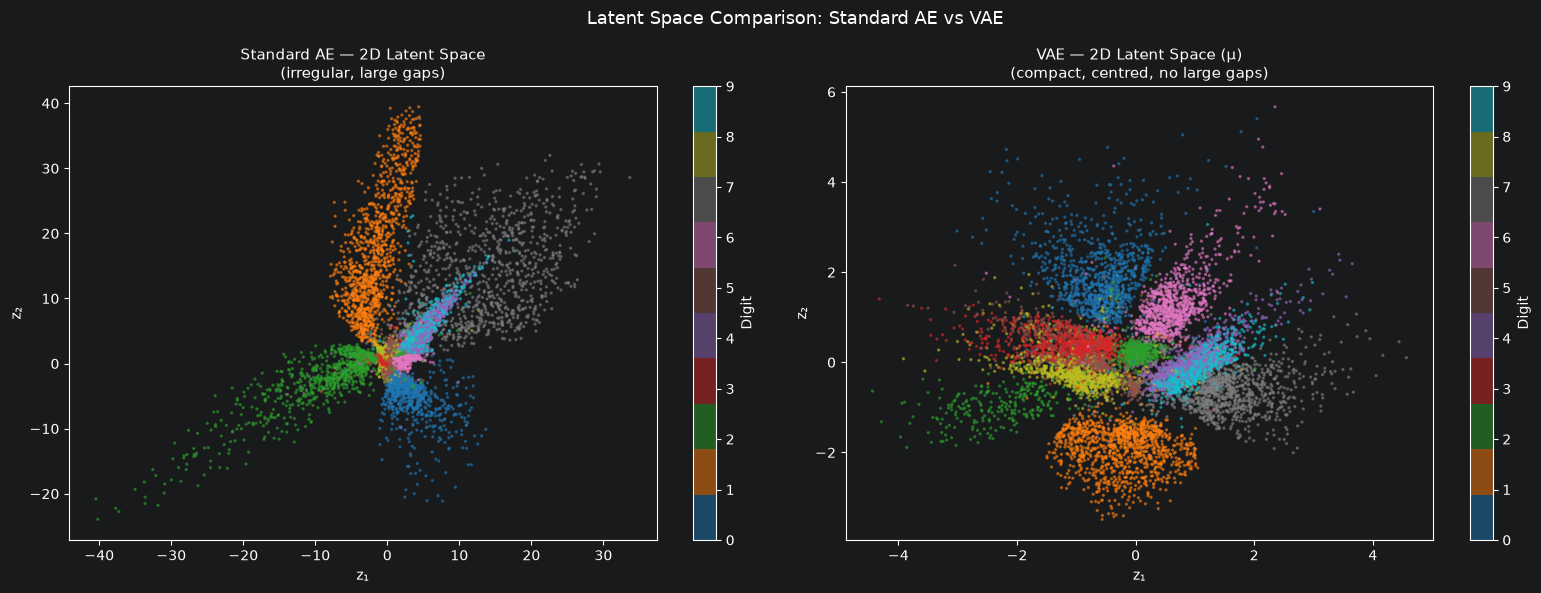

Key observation: the VAE latent space is centred around (0,0) and more compact.
This is a direct result of the KL divergence pushing the latent distribution toward N(0,I).
It means random samples from N(0,1) will reliably land in meaningful regions.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Standard AE latent space (from Part 6)
sc1 = axes[0].scatter(all_z[:,  0], all_z[:, 1],
                      c=all_labels,     cmap='tab10', s=2, alpha=0.5)
axes[0].set_title('Standard AE — 2D Latent Space\n(irregular, large gaps)', fontsize=11)
axes[0].set_xlabel('z₁')
axes[0].set_ylabel('z₂')
plt.colorbar(sc1, ax=axes[0], label='Digit')

# Right: VAE latent space
sc2 = axes[1].scatter(all_mu[:, 0], all_mu[:, 1],
                      c=all_labels_vae, cmap='tab10', s=2, alpha=0.5)
axes[1].set_title('VAE — 2D Latent Space (μ)\n(compact, centred, no large gaps)', fontsize=11)
axes[1].set_xlabel('z₁')
axes[1].set_ylabel('z₂')
plt.colorbar(sc2, ax=axes[1], label='Digit')

plt.suptitle('Latent Space Comparison: Standard AE vs VAE', fontsize=13)
plt.tight_layout()
plt.show()

print("Key observation: the VAE latent space is centred around (0,0) and more compact.")
print("This is a direct result of the KL divergence pushing the latent distribution toward N(0,I).")
print("It means random samples from N(0,1) will reliably land in meaningful regions.")


---
## Part 15: Interpolation in Latent Space

One of the most striking properties of a well-trained VAE latent space is **smooth interpolation**.

If you encode two different images (say a "3" and an "8"), then linearly move between their
latent means, each intermediate point should decode to a **smooth visual blend** - not noise.

This is only possible because the VAE's KL regularisation ensures there are no "holes" between clusters.


### Step 1 — Define the interpolation function

We encode two images to get their latent means μ₁ and μ₂, then compute
`z(t) = (1-t)·μ₁ + t·μ₂` for t in [0,1].

This is a **linear path** through latent space from one image to another.


In [26]:
def interpolate(model, img1, img2, steps=10):
    """
    Encode two images → get their latent means → linearly interpolate → decode each step.
    Returns a tensor of decoded images along the interpolation path.
    """
    model.eval()
    with torch.no_grad():
        mu1, _ = model.encode(img1.unsqueeze(0).to(device))   # latent mean of img1
        mu2, _ = model.encode(img2.unsqueeze(0).to(device))   # latent mean of img2

        # Linear interpolation: z(t) = (1-t)*mu1 + t*mu2  for t in [0, 1]
        # t=0 → mu1 (first image), t=1 → mu2 (second image)
        alphas   = torch.linspace(0, 1, steps)   # steps evenly spaced values from 0 to 1
        z_interp = torch.stack([(1 - a) * mu1 + a * mu2 for a in alphas]).squeeze(1)

        decoded = model.decode(z_interp)   # decode all intermediate points at once

    return decoded


### Step 2 — Find one example of each digit class

We scan the test set to find the first occurrence of each digit (0–9).
These serve as the start and end points of our interpolation paths.


In [27]:
digit_imgs = {}
for img, label in test_dataset:
    if label not in digit_imgs:
        digit_imgs[label] = img
    if len(digit_imgs) == 10:
        break   # stop once we have one of each digit

print("Found one image of each digit:")
print({k: f"digit {k}" for k in sorted(digit_imgs.keys())})


Found one image of each digit:
{0: 'digit 0', 1: 'digit 1', 2: 'digit 2', 3: 'digit 3', 4: 'digit 4', 5: 'digit 5', 6: 'digit 6', 7: 'digit 7', 8: 'digit 8', 9: 'digit 9'}


### Step 3 — Interpolate between pairs of digits

Each row shows a smooth transition between two different digit classes.
The leftmost image is the start digit, the rightmost is the end digit.
Intermediate images should look like gradual blends - not noise.

If the VAE is well-trained, you will see the digit gradually change shape and style
as we move through the latent space.


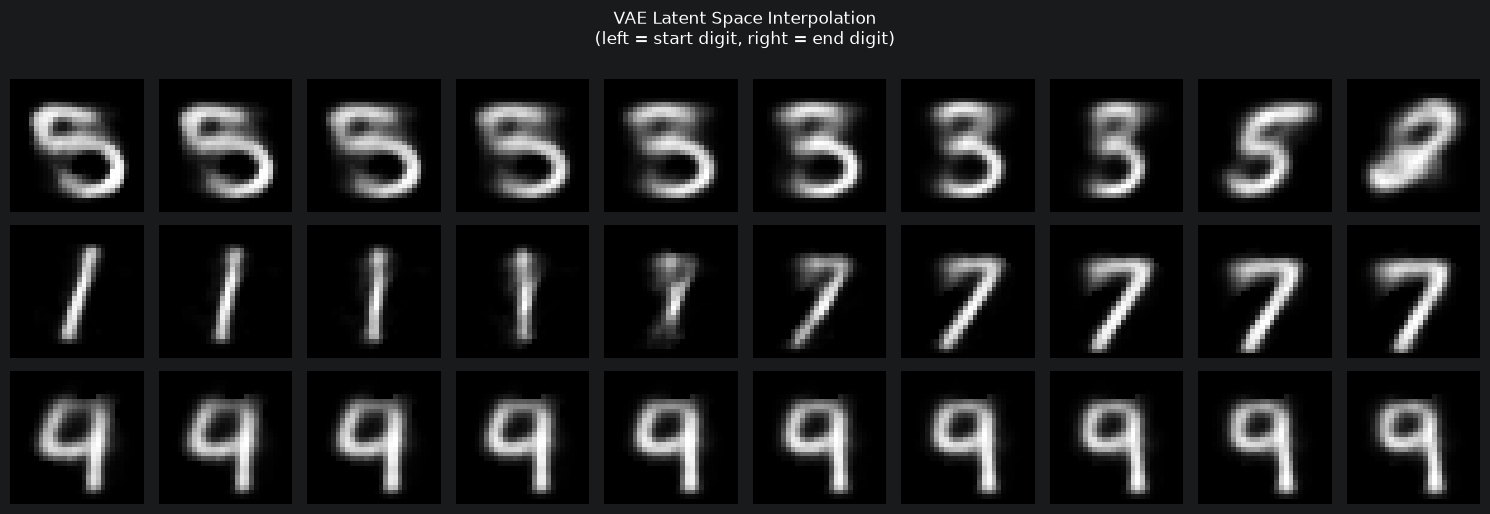

Each row smoothly transitions between two digit classes.
This confirms the VAE latent space is continuous and has no 'holes'.


In [28]:
pairs = [(3, 8), (1, 7), (4, 9)]

fig, axes = plt.subplots(len(pairs), 10, figsize=(15, 1.6 * len(pairs) + 0.5))

for row, (d1, d2) in enumerate(pairs):
    imgs_interp = interpolate(vae_2d, digit_imgs[d1], digit_imgs[d2], steps=10)
    for col in range(10):
        axes[row, col].imshow(imgs_interp[col].cpu().squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'{d1} → {d2}', fontsize=10)

plt.suptitle('VAE Latent Space Interpolation\n(left = start digit, right = end digit)')
plt.tight_layout()
plt.show()

print("Each row smoothly transitions between two digit classes.")
print("This confirms the VAE latent space is continuous and has no 'holes'.")


---
## Part 16: Exploring the 2D Latent Space as a Grid

Because the VAE latent space is 2D, we can decode every point on a regular grid
to produce a visual map of the entire learned space.

This shows:
- What the decoder has learned at every position
- Where different digits are concentrated
- How smoothly the space transitions between digit regions


### Step 1 — Define the grid

We sweep both latent dimensions from −3 to +3 in `grid_size` steps.
The range (−3, 3) covers roughly 99.7% of the N(0,1) distribution (3 standard deviations).
Points outside this range would rarely be sampled from N(0,I).


In [29]:
grid_size = 15    # 15×15 = 225 latent points to decode
limit     = 3.0   # sweep z from -3 to +3 (covers ≈99.7% of N(0,1))

# Create 1D grids along each axis
z1_vals = torch.linspace(-limit, limit, grid_size)   # x-axis values
z2_vals = torch.linspace(-limit, limit, grid_size)   # y-axis values

print(f"Grid: {grid_size}×{grid_size} = {grid_size**2} latent points")
print(f"Range: [{-limit}, {limit}] on each axis")
print(f"Canvas size: {28*grid_size}×{28*grid_size} pixels")


Grid: 15×15 = 225 latent points
Range: [-3.0, 3.0] on each axis
Canvas size: 420×420 pixels


### Step 2 — Decode every grid point and assemble the canvas

We decode each `(z1, z2)` pair and paste the resulting 28×28 image into the correct position
on a large canvas. The canvas is then one big image showing the whole latent space.

Pixel rescaling: the decoder outputs values in (−1, 1) because of `Tanh`.
We convert back to (0, 1) with `(pixel + 1) / 2` for display.


In [30]:
vae_2d.eval()
canvas = np.zeros((28 * grid_size, 28 * grid_size))   # blank canvas

with torch.no_grad():
    for i, z2 in enumerate(z2_vals):          # row index (y-axis)
        for j, z1 in enumerate(z1_vals):      # column index (x-axis)
            z = torch.tensor([[z1.item(), z2.item()]]).to(device)   # one latent point
            img = vae_2d.decode(z)                                  # decode → (1,1,28,28)
            img_np = img.cpu().squeeze().numpy()
            img_np = (img_np + 1) / 2   # rescale from (-1,1) to (0,1) for display
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img_np  # paste into canvas


### Step 3 — Display the full latent space map


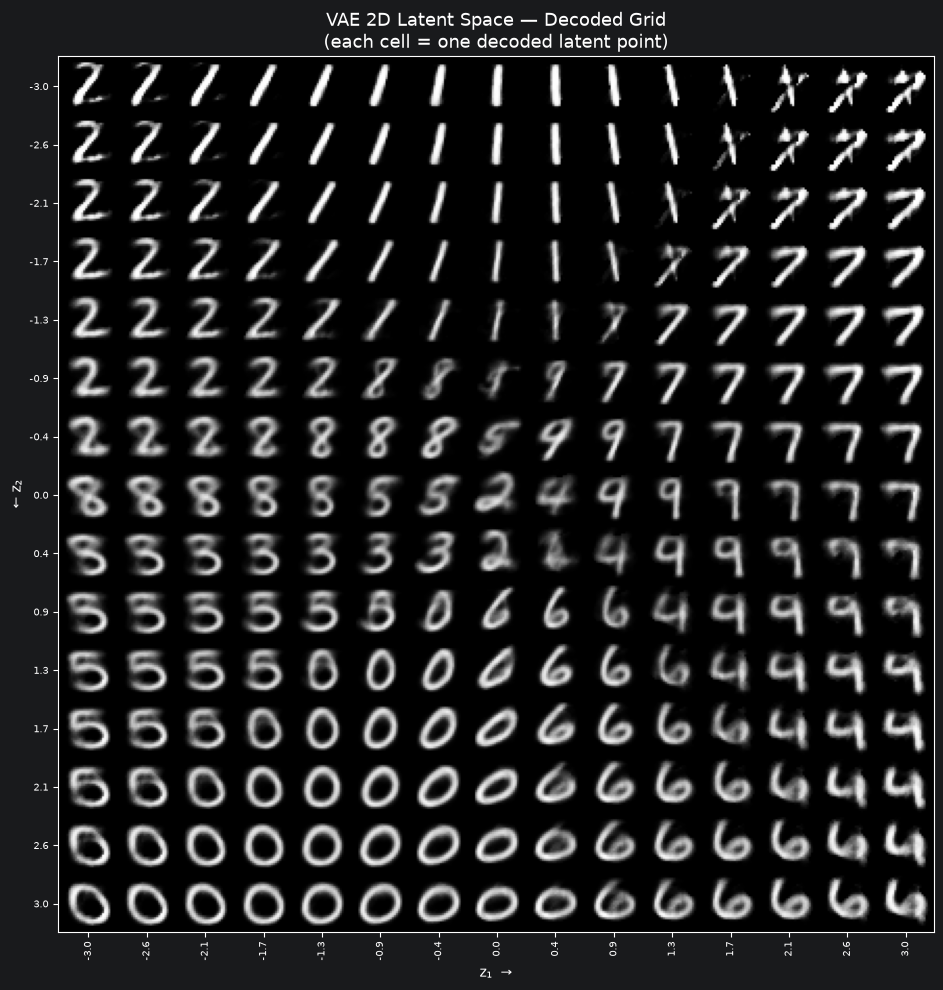

Observation: the grid shows smooth transitions across the latent space.
Digits near the centre (0,0) are clearest — they are most frequently sampled by N(0,I).
The edges (±3) produce blurrier or less recognisable images — they are rarely sampled.


In [31]:
plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap='gray')
plt.title('VAE 2D Latent Space — Decoded Grid\n(each cell = one decoded latent point)', fontsize=13)
plt.xlabel('z₁  →')
plt.ylabel('← z₂')
plt.xticks(np.arange(grid_size) * 28 + 14, [f'{v:.1f}' for v in z1_vals.numpy()], rotation=90, fontsize=7)
plt.yticks(np.arange(grid_size) * 28 + 14, [f'{v:.1f}' for v in z2_vals.numpy()], fontsize=7)
plt.tight_layout()
plt.show()

print("Observation: the grid shows smooth transitions across the latent space.")
print("Digits near the centre (0,0) are clearest — they are most frequently sampled by N(0,I).")
print("The edges (±3) produce blurrier or less recognisable images — they are rarely sampled.")


---
## Part 17: Exercises

###  Exercise 2 — Understanding the reparameterisation trick

1. The line `std = torch.exp(0.5 * log_var)` converts log variance to standard deviation. Calculate manually: if `log_var = 0`, what is `std`? If `log_var = 2`, what is `std`? If `log_var = -2`?
2. Why must we use `torch.randn_like(std)` rather than `torch.randn(std.shape)` when the model is on GPU?
3. In one sentence: why does `reparameterise` return just `mu` (not a sample) when `model.eval()` is called?


In [32]:
import math

# 1. Manual std computation: std = exp(0.5 * log_var)
print("1. std = exp(0.5 * log_var):")
for lv in [0, 2, -2]:
    std = math.exp(0.5 * lv)
    print(f"   log_var = {lv:2d}  →  std = exp(0.5 × {lv}) = {std:.4f}")

print()
print("Interpretation:")
print("  log_var=0  → std=1.0  → unit Gaussian (same as N(0,1)) ← perfect regularisation")
print("  log_var=2  → std=2.7  → wider distribution, more uncertain")
print("  log_var=-2 → std=0.37 → narrower distribution, more certain")

# 2. randn_like vs randn — device safety
print("\n2. Device safety:")
print("  torch.randn(std.shape)    → always creates tensor on CPU (crashes on GPU)")
print("  torch.randn_like(std)     → creates tensor on SAME DEVICE as std (safe on GPU)")
demo = torch.randn_like(torch.zeros(3, device=device))
print(f"  torch.randn_like result device: {demo.device}")

# 3. Answer:
print("\n3. During inference (eval), we use mu directly because:")
print("   - No gradient tracking is needed")
print("   - Using mu (not a sample) gives deterministic, reproducible reconstructions")
print("   - The random noise eps would only add variability without improving quality at test time")


1. std = exp(0.5 * log_var):
   log_var =  0  →  std = exp(0.5 × 0) = 1.0000
   log_var =  2  →  std = exp(0.5 × 2) = 2.7183
   log_var = -2  →  std = exp(0.5 × -2) = 0.3679

Interpretation:
  log_var=0  → std=1.0  → unit Gaussian (same as N(0,1)) ← perfect regularisation
  log_var=2  → std=2.7  → wider distribution, more uncertain
  log_var=-2 → std=0.37 → narrower distribution, more certain

2. Device safety:
  torch.randn(std.shape)    → always creates tensor on CPU (crashes on GPU)
  torch.randn_like(std)     → creates tensor on SAME DEVICE as std (safe on GPU)
  torch.randn_like result device: cpu

3. During inference (eval), we use mu directly because:
   - No gradient tracking is needed
   - Using mu (not a sample) gives deterministic, reproducible reconstructions
   - The random noise eps would only add variability without improving quality at test time


###  Exercise 3 — Understanding KL divergence

1. Compute the KL divergence for `mu=[0,0], log_var=[0,0]` (a perfect standard Gaussian). What value do you expect?
2. Compute it for `mu=[2,2], log_var=[0,0]`. How does it change and why?
3. What would happen to the reconstructions if we set β=0 (remove the KL term entirely)?


In [33]:
def kl_manual(mu_vals, lv_vals):
    """Compute KL divergence from the closed-form formula."""
    mu  = torch.tensor([mu_vals],  dtype=torch.float32)
    lv  = torch.tensor([lv_vals],  dtype=torch.float32)
    return -0.5 * torch.sum(1 + lv - mu**2 - torch.exp(lv)).item()

# 1. Perfect standard Gaussian: mu=0, log_var=0 → var=1 → N(0,1) = prior
kl1 = kl_manual([0.0, 0.0], [0.0, 0.0])
print(f"1. KL( N(mu=[0,0], var=1) || N(0,I) ) = {kl1:.4f}")
print("   Expected: 0.0 — the encoder matches the prior perfectly")

# 2. Shifted mean: mu=2, same variance
kl2 = kl_manual([2.0, 2.0], [0.0, 0.0])
print(f"\n2. KL( N(mu=[2,2], var=1) || N(0,I) ) = {kl2:.4f}")
print("   KL increased because mu is far from 0.")
print("   During training, this loss penalises the encoder and pushes mu back toward 0.")

# 3. Answer
print("\n3. Setting β=0 removes the KL term → the VAE becomes a standard Autoencoder.")
print("   Reconstructions may be sharper, but the latent space loses structure.")
print("   Random sampling from N(0,1) will mostly produce noise, not meaningful images.")


1. KL( N(mu=[0,0], var=1) || N(0,I) ) = -0.0000
   Expected: 0.0 — the encoder matches the prior perfectly

2. KL( N(mu=[2,2], var=1) || N(0,I) ) = 4.0000
   KL increased because mu is far from 0.
   During training, this loss penalises the encoder and pushes mu back toward 0.

3. Setting β=0 removes the KL term → the VAE becomes a standard Autoencoder.
   Reconstructions may be sharper, but the latent space loses structure.
   Random sampling from N(0,1) will mostly produce noise, not meaningful images.


###  Exercise 4 — β-VAE: Tuning the eeconstruction–regularisation trade-off

Train three VAEs with β=0.1, β=1.0, and β=4.0.
Compare the final reconstruction loss, KL divergence, and visual quality.

Fill in the table after running the cell:

| β | Recon Loss | KL Divergence | Observation |
|---|-----------|---------------|-------------|
| 0.1 | ? | ? | |
| 1.0 | ? | ? | |
| 4.0 | ? | ? | |


#### Step 1 — Train one VAE for each β value


In [34]:
beta_results = {}

for beta in [0.1, 1.0, 4.0]:
    torch.manual_seed(42)
    m = VAE(latent_dim=16).to(device)
    h = train_vae(m, train_loader, test_loader, epochs=15, beta=beta)
    beta_results[beta] = {'model': m, 'history': h}
    print(f"β={beta:.1f} | Final Recon: {h['val_recon'][-1]:.3f} | KL: {h['val_kl'][-1]:.3f}")


Epoch   1/15 | Train Loss: 141.025 (Recon: 136.874, KL: 41.513) | Val Loss: 85.093
Epoch   6/15 | Train Loss: 48.674 (Recon: 43.803, KL: 48.707) | Val Loss: 45.981
Epoch  11/15 | Train Loss: 42.172 (Recon: 37.334, KL: 48.389) | Val Loss: 40.583
Epoch  15/15 | Train Loss: 39.685 (Recon: 34.844, KL: 48.409) | Val Loss: 38.496
β=0.1 | Final Recon: 33.624 | KL: 48.724
Epoch   1/15 | Train Loss: 168.098 (Recon: 157.146, KL: 10.952) | Val Loss: 113.744
Epoch   6/15 | Train Loss: 79.683 (Recon: 58.464, KL: 21.219) | Val Loss: 71.585
Epoch  11/15 | Train Loss: 73.439 (Recon: 51.385, KL: 22.054) | Val Loss: 66.877
Epoch  15/15 | Train Loss: 71.141 (Recon: 48.815, KL: 22.326) | Val Loss: 64.410
β=1.0 | Final Recon: 41.622 | KL: 22.788
Epoch   1/15 | Train Loss: 194.155 (Recon: 179.580, KL: 3.644) | Val Loss: 142.231
Epoch   6/15 | Train Loss: 126.849 (Recon: 90.192, KL: 9.164) | Val Loss: 112.025
Epoch  11/15 | Train Loss: 121.424 (Recon: 82.379, KL: 9.761) | Val Loss: 106.033
Epoch  15/15 | Tra

#### Step 2 — Compare reconstructions side by side

Look at the image quality for each β value.
A low β (weak regularisation) should give sharper images but a less useful latent space.
A high β (strong regularisation) should give blurrier images but a more structured latent space.


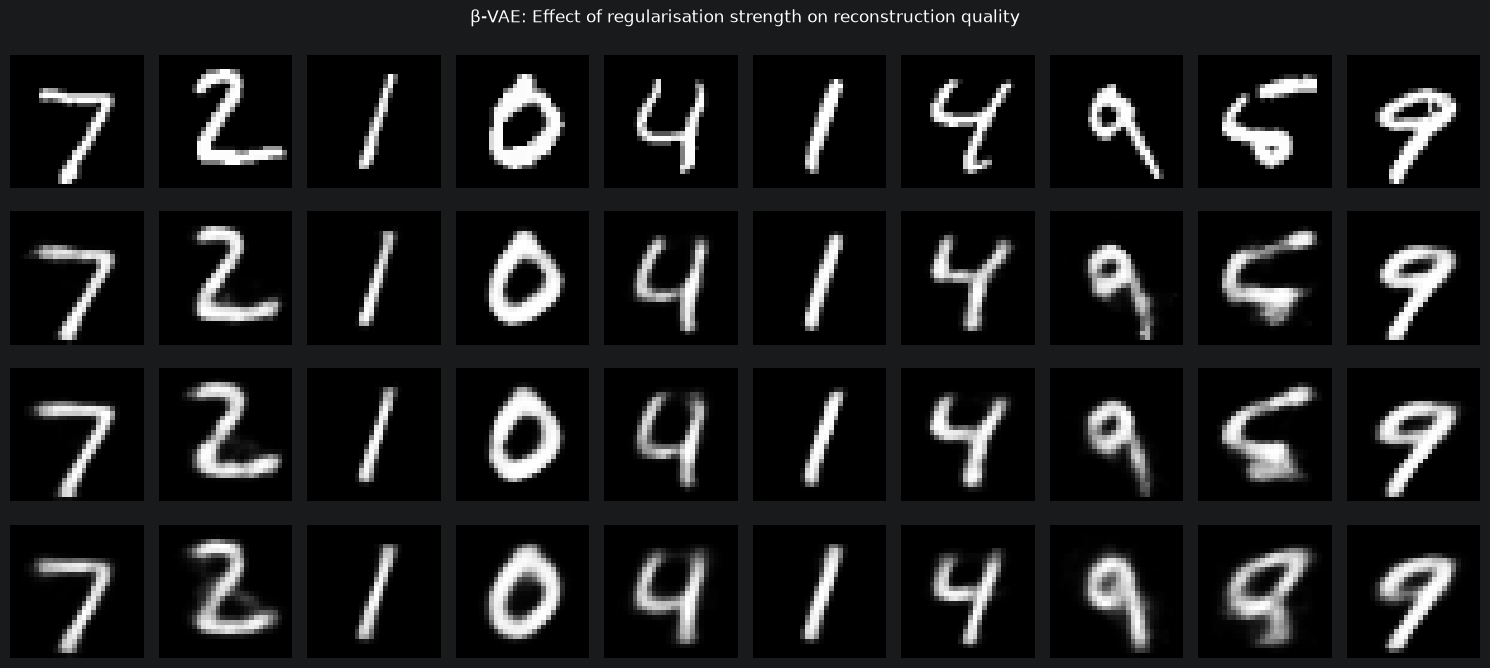

β=0.1 → sharp reconstructions (weak regularisation, latent space less structured)
β=4.0 → blurrier reconstructions (strong regularisation, latent space more structured)


In [35]:
imgs = torch.stack([test_dataset[i][0] for i in range(10)]).to(device)

fig, axes = plt.subplots(len(beta_results) + 1, 10,
                          figsize=(15, 1.6 * (len(beta_results) + 1) + 0.5))

# Row 0: originals
for i in range(10):
    axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

# Rows 1+: one row per β value
for row, (beta, res) in enumerate(beta_results.items(), start=1):
    res['model'].eval()
    with torch.no_grad():
        recons, _, _ = res['model'](imgs)
    for i in range(10):
        axes[row, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'β = {beta}', fontsize=9)

plt.suptitle('β-VAE: Effect of regularisation strength on reconstruction quality')
plt.tight_layout()
plt.show()

print("β=0.1 → sharp reconstructions (weak regularisation, latent space less structured)")
print("β=4.0 → blurrier reconstructions (strong regularisation, latent space more structured)")


---
## Part 18: Saving and Loading the VAE

Same pattern as Tutorial 1: save the `state_dict`, recreate the architecture, load it back.


### Step 1 — Save the trained model weights to disk

`state_dict()` returns a dictionary of all learnable parameters.
We save it to a `.pth` file (PyTorch convention).


In [36]:
torch.save(vae.state_dict(), 'vae_mnist.pth')
print("Saved: vae_mnist.pth")
print("Contents: all learnable parameters (weights and biases) as a state dictionary")

# Show what keys are saved (layer names)
state = torch.load('vae_mnist.pth', map_location='cpu')
print(f"\nNumber of parameter tensors saved: {len(state)}")
for key in list(state.keys())[:5]:   # show first 5 keys
    print(f"  {key}: shape {state[key].shape}")
print("  ...")


Saved: vae_mnist.pth
Contents: all learnable parameters (weights and biases) as a state dictionary

Number of parameter tensors saved: 14
  encoder_body.0.weight: shape torch.Size([256, 784])
  encoder_body.0.bias: shape torch.Size([256])
  encoder_body.2.weight: shape torch.Size([64, 256])
  encoder_body.2.bias: shape torch.Size([64])
  fc_mu.weight: shape torch.Size([16, 64])
  ...


### Step 2 — Load the model back and verify it produces identical outputs

**Critical:** You must create a model with the **same architecture** (`latent_dim=16`) before loading.
The `load_state_dict` call fills in the weights; it does not recreate the architecture.


In [37]:
# Recreate the architecture — must match what was saved
loaded_vae = VAE(latent_dim=16)   # same latent_dim as the saved model!
loaded_vae.load_state_dict(torch.load('vae_mnist.pth', map_location='cpu'))
loaded_vae.eval()
print("Loaded: VAE(latent_dim=16) from vae_mnist.pth")

# Verify outputs are identical
vae.eval()
with torch.no_grad():
    test_img = test_dataset[0][0].unsqueeze(0)
    out1, mu1, _ = vae(test_img.to(device))     # original model
    out2, mu2, _ = loaded_vae(test_img)          # loaded model (on CPU)

print("\nVerification:")
print(f"  Reconstructions match : {torch.allclose(out1.cpu(), out2, atol=1e-5)}")
print(f"  Latent means match    : {torch.allclose(mu1.cpu(),  mu2, atol=1e-5)}")


Loaded: VAE(latent_dim=16) from vae_mnist.pth

Verification:
  Reconstructions match : True
  Latent means match    : True
